Dataset created in memory (40 rows)
Shape: (40, 14)

Target distribution:
 target
0    0.575
1    0.425
Name: proportion, dtype: float64

RIDGE RESULTS
MAE: 0.6198314667605616
RMSE: 0.846051316657521
R2: 0.5667053084637259

LASSO RESULTS
MAE: 0.6614943014829462
RMSE: 0.9820400292255423
R2: 0.41622117493867805


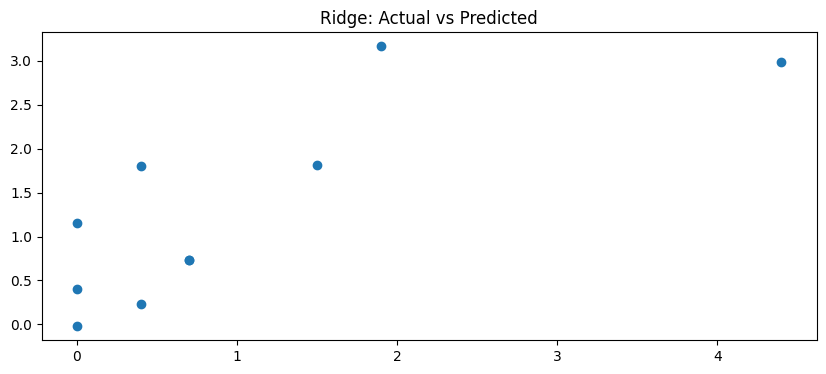

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create dataset directly in memory (40 rows)
data = {
    'age': [52,53,70,61,62,58,58,55,46,54,71,43,34,51,52,34,51,54,50,58,
            60,67,45,63,42,61,44,58,56,55,44,50,57,70,50,46,51,59,64,57],
    'sex': [1,1,1,1,0,0,1,1,1,1,0,0,0,1,1,0,0,1,0,1,
            1,0,1,0,0,0,1,0,1,0,1,0,1,1,1,1,1,1,1,1],
    'cp': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,0,1,2,
           2,0,0,2,2,0,2,1,2,0,0,1,0,2,2,2,3,0,0,2],
    'trestbps': [125,140,145,148,138,100,114,160,120,122,112,132,118,140,128,118,140,124,120,140,
                 140,106,104,135,120,145,130,136,130,180,120,120,130,160,129,150,125,138,128,128],
    'chol': [212,203,174,203,294,248,318,289,249,286,149,341,210,298,204,210,308,266,244,211,
             185,223,208,252,209,307,233,319,256,327,169,244,131,269,196,231,213,271,263,229],
    'fbs': [0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,
            0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0],
    'restecg': [1,0,1,1,1,0,2,0,0,0,1,0,1,1,1,1,0,0,1,0,
                0,1,0,0,1,0,1,0,0,2,1,1,1,1,1,1,0,0,1,0],
    'thalach': [168,155,125,161,106,122,140,145,144,116,125,136,192,122,156,192,142,109,162,165,
                155,142,148,172,173,146,179,152,142,117,144,162,115,112,163,147,125,182,105,150],
    'exang': [0,1,1,0,0,0,0,1,0,1,0,1,0,1,1,0,0,1,0,0,
              0,0,1,0,0,1,1,0,1,1,1,0,1,1,0,0,1,0,1,0],
    'oldpeak': [1.0,3.1,2.6,0.0,1.9,1.0,4.4,0.8,0.8,3.2,1.6,3.0,0.7,4.2,1.0,0.7,1.5,2.2,1.1,0.0,
                3.0,0.3,3.0,0.0,0.0,1.0,0.4,0.0,0.6,3.4,2.8,1.1,1.2,2.9,0.0,3.6,1.4,0.0,0.2,0.4],
    'slope': [2,0,0,2,1,1,0,1,2,1,1,1,2,1,1,2,2,1,2,2,
              1,2,1,2,1,1,2,2,1,1,0,2,1,1,2,1,2,2,1,1],
    'ca': [2,0,0,1,3,0,3,1,0,2,0,0,0,3,0,0,1,1,0,0,
           0,2,0,0,0,0,0,2,1,0,0,0,1,1,0,0,1,0,1,1],
    'thal': [3,3,3,3,2,2,1,3,3,2,2,3,2,3,0,2,2,3,2,2,
             2,2,2,2,2,3,2,2,1,2,1,2,3,3,2,2,2,2,3,3],
    'target': [0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,1,1,
               0,1,1,1,1,0,1,0,0,0,0,1,0,0,1,0,1,1,1,0]
}

df = pd.DataFrame(data)

print("Dataset created in memory (40 rows)")
print("Shape:", df.shape)
print("\nTarget distribution:\n", df['target'].value_counts(normalize=True))

X = df.drop(['oldpeak', 'target'], axis=1)
y = df['oldpeak']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("\nRIDGE RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2:", r2_score(y_test, y_pred_ridge))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("\nLASSO RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))

plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred_ridge)
plt.title("Ridge: Actual vs Predicted")
plt.show()